In [1]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.logger_utils import setup_clean_logger, mute_external_loggers

# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as svp

# --- Runtime configuration ---
warnings.filterwarnings("ignore")

# Set up a clean logger for your notebook
logger = setup_clean_logger("notebook", logging.INFO)
logger.info("Notebook started successfully.")

# Mute logs from sisepuede to avoid duplication
mute_external_loggers(["sisepuede"])


2026-03-24 19:45:13,958 - INFO - Notebook started successfully.


In [2]:
%load_ext autoreload
%autoreload 2

### Initial Set up

Make sure to edit the config yaml under ssp_modeling/config_files/config.yaml

You can also create a new config yaml



In [3]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
SCENARIO_MAPPING_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("scenario_mapping")
CONFIG_DIR_PATH = CURR_DIR_PATH.joinpath("config_files")
TRANSFORMATIONS_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("transformations")
MISC_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("misc")
STRATEGIES_DEFINITIONS_FILE_PATH = TRANSFORMATIONS_DIR_PATH.joinpath("strategy_definitions.csv")
STRATEGY_MAPPING_FILE_PATH = MISC_DIR_PATH.joinpath("strategy_mapping.yaml")

In [4]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils
from ssp_transformations_handler.TransformationUtils import TransformationYamlProcessor, StrategyCSVHandler

# Initialize general utilities
g_utils = GeneralUtils()

In [5]:
# Load config file, double check your parameters are correct

YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
ssp_input_file_name = config_params['ssp_input_file_name']
ssp_transformation_cw = config_params['ssp_transformation_cw']
energy_model_flag = config_params['energy_model_flag']
set_lndu_reallocation_factor_to_zero_flag = config_params['set_lndu_reallocation_factor_to_zero']
sim_end_year = config_params.get('sim_end_year', 2050)  # Default to 2050 if not specified

# Print config parameters
logger.info(f"Country name: {country_name}")
logger.info(f"SSP input file name: {ssp_input_file_name}")
logger.info(f"SSP transformation CW: {ssp_transformation_cw}")
logger.info(f"Energy model flag: {energy_model_flag}")
logger.info(f"Set lndu reallocation factor to zero flag: {set_lndu_reallocation_factor_to_zero_flag}")
logger.info(f"Simulation end year: {sim_end_year}")

2026-03-24 19:45:14,053 - INFO - Country name: libya
2026-03-24 19:45:14,054 - INFO - SSP input file name: sisepuede_raw_inputs_latest_mar.csv
2026-03-24 19:45:14,054 - INFO - SSP transformation CW: ssp_libya_transformation_cw_20260310.xlsx
2026-03-24 19:45:14,054 - INFO - Energy model flag: True
2026-03-24 19:45:14,054 - INFO - Set lndu reallocation factor to zero flag: True
2026-03-24 19:45:14,054 - INFO - Simulation end year: 2050


In [6]:
def get_file_structure(
    y0: int = 2015,
    y1: int = sim_end_year,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    # setup some SISEPUEDE variables and update time period
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    # get some keys
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year
 
 
    ##  BUILD THE ATTRIBUTE AND UPDATE
 
    # setup the new attribute table
    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    # finally, update the ModelAttributes inside the file structure
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    # return the tuple
    out = (file_struct, attribute_time_period, )
 
    return out


In [7]:
# Set up SSP objects
INPUT_FILE_PATH = DATA_DIR_PATH.joinpath(ssp_input_file_name)

# model attributes and associated support classes
_EXAMPLES = sxl.SISEPUEDEExamples()
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure(y1=sim_end_year)
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )
 

### Making sure our input file has the correct format and correct columns
We use an example df with the complete fields and correct format to make sure our file is in the right shape

In [8]:
##  BUILD BASE INPUTS
df_inputs_raw = pd.read_csv(INPUT_FILE_PATH)

# pull example data to fill in gaps
df_example_input = _EXAMPLES("input_data_frame")

In [9]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [10]:
all_fields = matt.all_variable_fields_input
df_fiels = df_inputs_raw.columns.tolist()
missing_fields = list(set(all_fields) - set(df_fiels))
print("Missing fields in the input data frame:")
print(missing_fields)

Missing fields in the input data frame:
[]


In [11]:
# Ensure if time_period field exist
if 'time_period' not in df_inputs_raw.columns:
    logger.info("Adding 'time_period' column to df_inputs_raw")
    df_inputs_raw = df_inputs_raw.rename(columns={'period':'time_period'})
else:
    logger.info("'time_period' column already exists in df_inputs_raw")

2026-03-24 19:45:14,773 - INFO - 'time_period' column already exists in df_inputs_raw


In [12]:
# Fixes differences and makes sure that our df is in the correct format.
# Note: Edit this if you need more changes in your df

df_inputs_raw_complete = g_utils.add_missing_cols(df_example_input, df_inputs_raw.copy())
df_inputs_raw_complete.head()

No missing columns to add.


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,region,population_gnrl_rural,population_gnrl_urban
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya,795843.0,5735976.0
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya,808058.0,5824068.0
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya,821006.0,5917764.0
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya,834319.0,6014736.0
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya,846496.0,6104537.0


In [13]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw_complete)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [14]:
df_inputs_raw_complete["region"].head()

0    libya
1    libya
2    libya
3    libya
4    libya
Name: region, dtype: object

In [15]:
# Set region to country name
df_inputs_raw_complete['region'] = country_name
df_inputs_raw_complete['region'].head()

0    libya
1    libya
2    libya
3    libya
4    libya
Name: region, dtype: object

In [16]:
# filter to match sim_end_year
print(f"min and max years in raw inputs before filtering: {df_inputs_raw_complete['year'].min()} to {df_inputs_raw_complete['year'].max()}")
df_inputs_raw_complete = df_inputs_raw_complete[df_inputs_raw_complete['year'] <= sim_end_year]
print(f"min and max years in raw inputs after filtering: {df_inputs_raw_complete['year'].min()} to {df_inputs_raw_complete['year'].max()}")

min and max years in raw inputs before filtering: 2015 to 2050
min and max years in raw inputs after filtering: 2015 to 2050


In [17]:
df_inputs_raw_complete[['time_period','qtyinit_soil_synthetic_fertilizer_kt']].head()

,time_period,qtyinit_soil_synthetic_fertilizer_kt
0,0,10.174
1,1,10.174
2,2,10.174
3,3,10.174
4,4,10.174


#  Let's try building transformations using this


In [18]:
import sisepuede.transformers as trf
transformers = trf.transformers.Transformers(
    {},
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = df_inputs_raw_complete,
)

##  Instantiate some transformations. Make sure to run this cell to create the transformations folder for the first time or if you wish to overwrite

In [19]:
# set an ouput path and instantiate
if not TRANSFORMATIONS_DIR_PATH.exists():
    trf.instantiate_default_strategy_directory(
        transformers,
        TRANSFORMATIONS_DIR_PATH,
    )
else:
    logger.info(f"Directory {TRANSFORMATIONS_DIR_PATH} already exists. Skipping instantiation.")


2026-03-24 19:45:15,303 - INFO - Directory /Users/fabianfuentes/git/ssp_libya/ssp_modeling/transformations already exists. Skipping instantiation.


##  --HERE, CUSTOMIZE YOUR TRANSFORMATIONS AND STRATEGIES--

### Customizing transformations and strategies files using TransformationUtils.py classes

In [20]:
# Generate new transformation files based on the excel mapping file. 
# Make sure to have the most updated format for the excel file, check the one used in this notebook for reference.

if ssp_transformation_cw is None:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")
else:
    logger.info(f"Using transformation file: {ssp_transformation_cw}")
    cw_file_path = os.path.join(SCENARIO_MAPPING_DIR_PATH, ssp_transformation_cw)
    logger.info(f"Transformation file path: {cw_file_path}")
    excel_yaml_handler = TransformationYamlProcessor(scenario_mapping_excel_path=cw_file_path, yaml_dir_path=TRANSFORMATIONS_DIR_PATH)

2026-03-24 19:45:15,315 - INFO - Using transformation file: ssp_libya_transformation_cw_20260310.xlsx
2026-03-24 19:45:15,316 - INFO - Transformation file path: /Users/fabianfuentes/git/ssp_libya/ssp_modeling/scenario_mapping/ssp_libya_transformation_cw_20260310.xlsx


In [21]:
# This creates transformation yaml files for each strategy in the excel file
if ssp_transformation_cw is not None:
    logger.info("Processing YAML files...")
    excel_yaml_handler.process_yaml_files()
else:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")

2026-03-24 19:45:15,411 - INFO - Processing YAML files...


[transformation_entc_dec_losses.yaml | TX:ENTC:DEC_LOSSES] Reduce transmission losses (ENTC) | Start: 12
Strategy: strategy_NDC, Scalar value: 0.3
[transformation_entc_dec_losses.yaml | TX:ENTC:DEC_LOSSES] Reduce transmission losses (ENTC) | Start: 12
Strategy: strategy_LEP, Scalar value: 0.3
[transformation_entc_target_renewable_elec.yaml | TX:ENTC:TARGET_RENEWABLE_ELEC] 95% of electricity is generated by renewables in 2050 (ENTC) | Start: 12
Strategy: strategy_NDC, Scalar value: 0.3
[transformation_entc_target_renewable_elec.yaml | TX:ENTC:TARGET_RENEWABLE_ELEC] 95% of electricity is generated by renewables in 2050 (ENTC) | Start: 12
Strategy: strategy_LEP, Scalar value: 0.3
[transformation_fgtv_dec_leaks.yaml | TX:FGTV:DEC_LEAKS] Minimize leaks (FGTV) | Start: 12
Strategy: strategy_NDC, Scalar value: 0.15
[transformation_fgtv_dec_leaks.yaml | TX:FGTV:DEC_LEAKS] Minimize leaks (FGTV) | Start: 12
Strategy: strategy_LEP, Scalar value: 0.3
[transformation_fgtv_inc_flare.yaml | TX:FGTV:I

In [22]:
# Load the transformations per strategy dictionary so we can pass it to the strategy handler
# You can also check here if the transformations in each strategy are correct

if ssp_transformation_cw is not None:
    logger.info("Loading transformations per strategy dictionary...")
    transformation_per_strategy_dict = excel_yaml_handler.get_transformations_per_strategy_dict()
    transformation_per_strategy_dict
    logger.info(f"Loaded transformations for strategies: {transformation_per_strategy_dict.keys()}")
else:
    logger.warning("No transformation handler available. Please check your config file.")

2026-03-24 19:45:15,460 - INFO - Loading transformations per strategy dictionary...
2026-03-24 19:45:15,461 - INFO - Loaded transformations for strategies: dict_keys(['strategy_NDC', 'strategy_LEP'])


### Creating new strategies
- You can create new strategies from scratch.
- You can also update existing ones.

In [23]:
# Creating new strategies by updating the strategy_definitions file.

if ssp_transformation_cw is not None:
    # You can edit this to add yours, as many as you want.
    csv_handler = StrategyCSVHandler(csv_file_path=STRATEGIES_DEFINITIONS_FILE_PATH, 
                                     yaml_dir_path=TRANSFORMATIONS_DIR_PATH, 
                                     yaml_mapping_file=STRATEGY_MAPPING_FILE_PATH, 
                                     transformation_per_strategy_dict=transformation_per_strategy_dict)
    csv_handler.add_strategy(strategy_group='PFLO', description='NDC', yaml_file_suffix='NDC')
    csv_handler.add_strategy(strategy_group='PFLO', description='LEP', yaml_file_suffix='LEP')
else:
    logger.warning("No transformation handler available. Please check your config file.")


INFO: Strategy code PFLO:NDC already exists in the strategy definitions. Strategy will be updated...
Updated row with strategy_code PFLO:NDC
INFO: Strategy code PFLO:LEP already exists in the strategy definitions. Strategy will be updated...
Updated row with strategy_code PFLO:LEP


In [24]:
# Set up the strategy codes you wish to run in ssp
strategies_to_run = [0,1008, 6030]

### We finished adding new transformation files and strategies so lets load them back

In [25]:
# then, you can load this back in after modifying (play around with it)
transformations = trf.Transformations(
    TRANSFORMATIONS_DIR_PATH,
    transformers = transformers,
)
tab = transformations.attribute_transformation.table

In [26]:
#  build the strategies -- will export to path
t0 = time.time()
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)

t_elapse = sf.get_time_elapsed(t0)
print(f"Strategies defined at {strategies.transformations.dir_init} initialized in {t_elapse} seconds")

Strategies defined at /Users/fabianfuentes/git/ssp_libya/ssp_modeling/transformations initialized in 21.15 seconds


##  Build our templates
- let's use the default variable groupings for LHS

In [27]:
# Building excel templates, make sure to include the strategies ids in the strategies attribute as well as the baseline (0)
df_vargroups = _EXAMPLES("variable_trajectory_group_specification")

strategies.build_strategies_to_templates(
    # df_trajgroup = df_vargroups,
    # include_simplex_group_as_trajgroup = True,
    strategies = strategies_to_run,
)

0

# Finally, load SISEPUEDE and run it

In [28]:
country_name

'libya'

In [29]:
import sisepuede as si
# timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    # id_str = f"sisepuede_run_2024-11-04T09:23:26.721580",
    initialize_as_dummy = not(energy_model_flag), # no connection to Julia is initialized if set to True
    regions = [country_name],
    strategies = strategies,
    # try_exogenous_xl_types_in_variable_specification = True,
    attribute_time_period=_ATTRIBUTE_TABLE_TIME_PERIOD
)

2026-03-24 19:45:40,079 - INFO - Successfully initialized SISEPUEDEFileStructure.
2026-03-24 19:45:40,080 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2026-03-24 19:45:40,080 - INFO - 	Setting export engine to 'csv'.
2026-03-24 19:45:40,081 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2026-03-24 19:45:40,081 - INFO - Successfully instantiated table ANALYSIS_METADATA
2026-03-24 19:45:40,081 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2026-03-24 19:45:40,082 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2026-03-24 19:45:40,082 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2026-03-24 19:45:40,082 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2026-03-24 19:45:40,082 - WARNING - No index fi

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1207.2 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2026-03-24 19:46:14,056 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2026-03-24 19:46:14,069 - INFO - Successfully initialized SISEPUEDEModels.
2026-03-24 19:46:14,074 - INFO - Table ANALYSIS_METADATA successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/p

In [30]:
# This runs the model, make sure you edit key_stretegy with the strategy ids you want to execute include baseline (0)
dict_scens = {
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: strategies_to_run,
}

ssp.project_scenarios(
    dict_scens,
    save_inputs = True,
    include_electricity_in_energy = energy_model_flag,
    # dict_optimizer_attributes = {"user_bound_scale": -7, }
)

2026-03-24 19:46:14,189 - INFO - 
***	STARTING REGION libya	***

2026-03-24 19:46:15,429 - INFO - Trying run primary_id = 0 in region libya
2026-03-24 19:46:15,429 - INFO - Running AFOLU model
2026-03-24 19:46:15,632 - INFO - AFOLU model run successfully completed
2026-03-24 19:46:15,633 - INFO - Running CircularEconomy model
2026-03-24 19:46:15,655 - INFO - CircularEconomy model run successfully completed
2026-03-24 19:46:15,655 - INFO - Running IPPU model
2026-03-24 19:46:15,691 - INFO - IPPU model run successfully completed
2026-03-24 19:46:15,691 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-24 19:46:15,701 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-24 19:46:15,743 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-24 19:46:15,743 - INFO - Running Energy model (Electricity and Fuel Production: trying to 

2026-24-Mar 19:46:16.116 Opened SQLite database at /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-24-Mar 19:46:16.135 Added NEMO structure to SQLite database at /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-24-Mar 19:46:30.407 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.


2026-03-24 19:47:24,637 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-24 19:47:24,657 - INFO - EnergyProduction model run successfully completed
2026-03-24 19:47:24,657 - INFO - Running Energy (Fugitive Emissions)
2026-03-24 19:47:24,679 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-24 19:47:24,679 - INFO - Appending Socioeconomic outputs
2026-03-24 19:47:24,684 - INFO - Socioeconomic outputs successfully appended.
2026-03-24 19:47:24,686 - INFO - Model run for primary_id = 0 successfully completed in 69.26 seconds (n_tries = 1).
2026-03-24 19:47:24,695 - INFO - Trying run primary_id = 9009 in region libya
2026-03-24 19:47:24,695 - INFO - Running AFOLU model


2026-24-Mar 19:46:30.871 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-24-Mar 19:46:51.670 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-24-Mar 19:46:51.747 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-24-Mar 19:47:24.488 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-24 19:47:24,909 - INFO - AFOLU model run successfully completed
2026-03-24 19:47:24,909 - INFO - Running CircularEconomy model
2026-03-24 19:47:24,945 - INFO - CircularEconomy model run successfully completed
2026-03-24 19:47:24,946 - INFO - Running IPPU model
2026-03-24 19:47:24,985 - INFO - IPPU model run successfully completed
2026-03-24 19:47:24,985 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-24 19:47:24,995 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-24 19:47:25,040 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-24 19:47:25,040 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


...

2026-24-Mar 19:48:19.133 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-24-Mar 19:48:19.178 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].


2026-03-24 19:49:09,530 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-24 19:49:09,540 - INFO - EnergyProduction model run successfully completed
2026-03-24 19:49:09,540 - INFO - Running Energy (Fugitive Emissions)
2026-03-24 19:49:09,565 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-24 19:49:09,565 - INFO - Appending Socioeconomic outputs
2026-03-24 19:49:09,571 - INFO - Socioeconomic outputs successfully appended.
2026-03-24 19:49:09,573 - INFO - Model run for primary_id = 101101 successfully completed in 51.41 seconds (n_tries = 1).
2026-03-24 19:49:09,580 - INFO - 
***	 REGION libya COMPLETE	***



2026-24-Mar 19:48:32.909 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-24-Mar 19:48:32.965 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-24-Mar 19:49:09.438 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-24 19:49:09,656 - INFO - Table MODEL_OUTPUT successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-24T19;45;39.793252/sisepuede_run_2026-03-24T19;45;39.793252_output_database/MODEL_OUTPUT.csv.
2026-03-24 19:49:09,658 - INFO - Table ATTRIBUTE_PRIMARY successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-24T19;45;39.793252/sisepuede_run_2026-03-24T19;45;39.793252_output_database/ATTRIBUTE_PRIMARY.csv.
2026-03-24 19:49:09,754 - INFO - Table MODEL_INPUT successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-24T19;45;39.793252/sisepuede_run_2026-03-24T19;45;39.793252_output_database/MODEL_INPUT.csv.


{'libya': [0, 9009, 101101]}

## Read simulations and check outputs

In [31]:
# Read input and output files
df_out = ssp.read_output(None)
df_in = ssp.read_input(None)

In [32]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[ssp.key_primary].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.show()

In [33]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

In [34]:
primary_ids_to_plot = df_out[ssp.key_primary].unique()

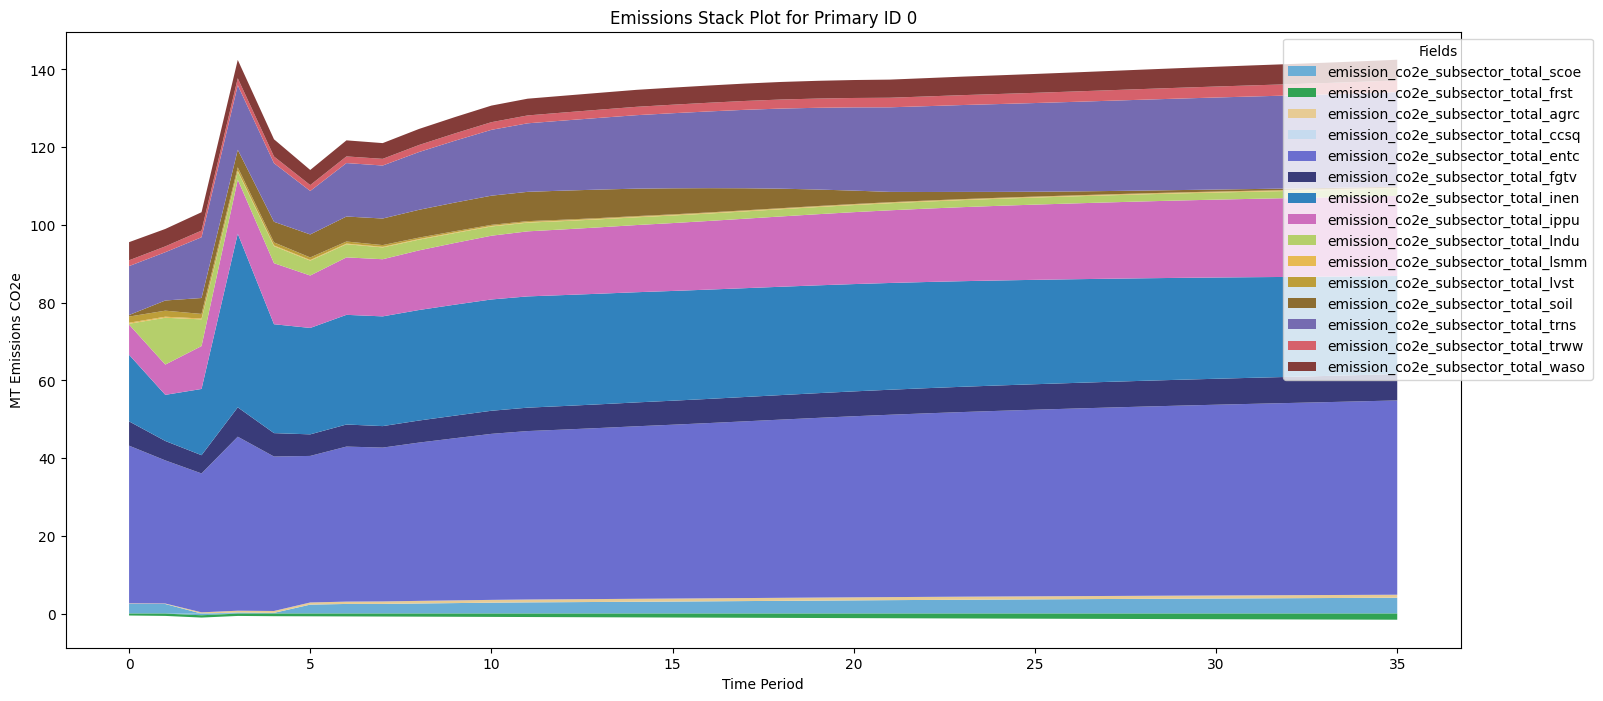

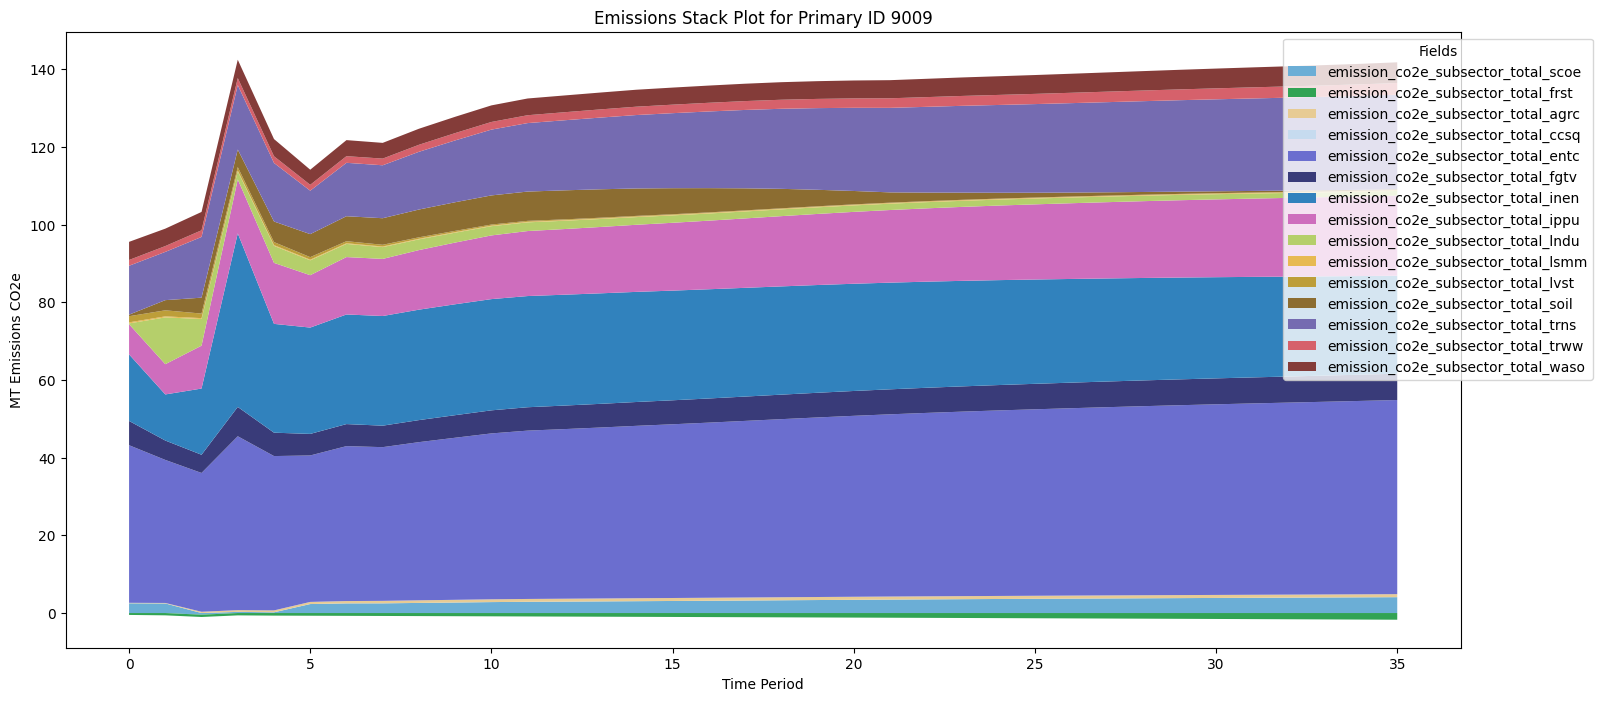

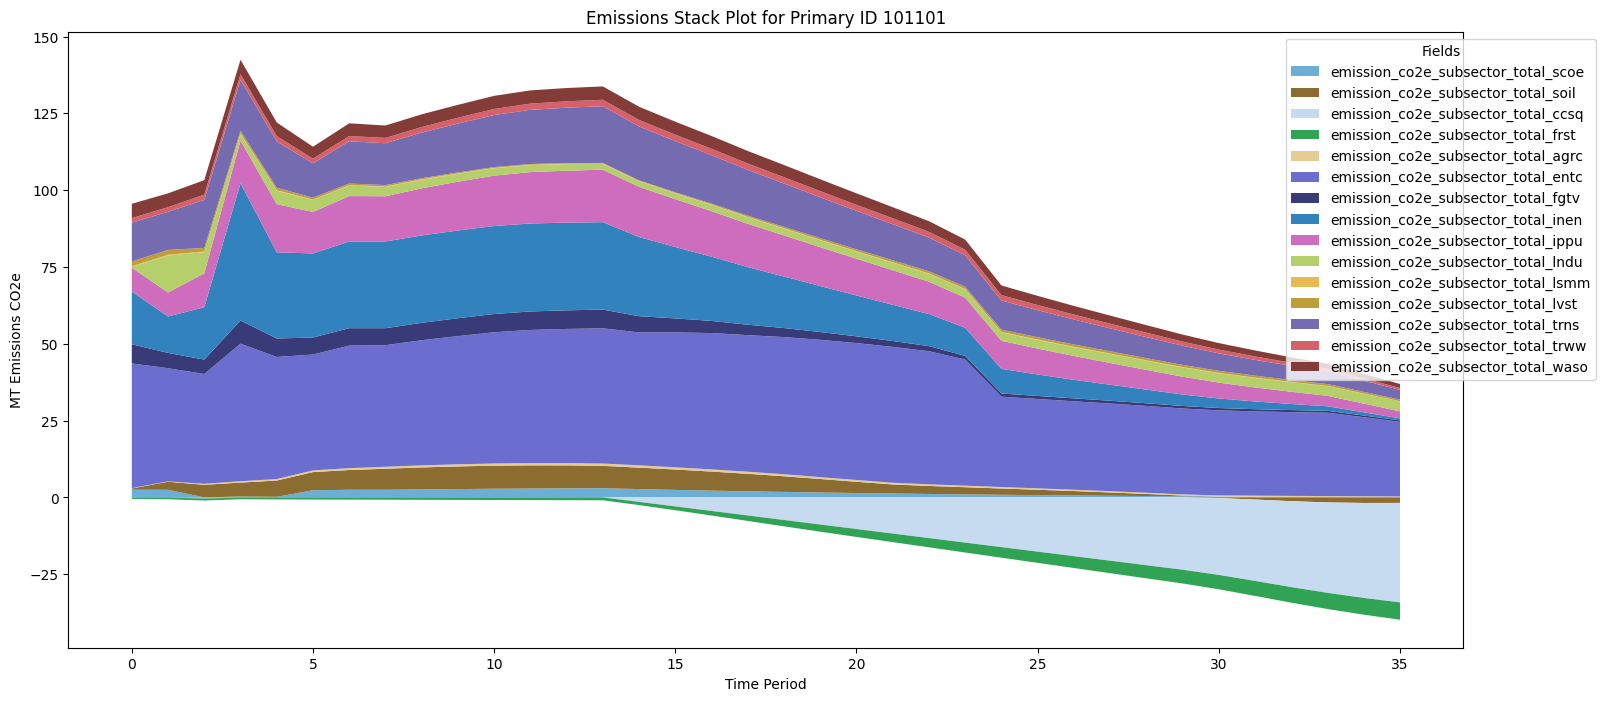

In [35]:
# Plot the emissions stack for the primary_id 0 (which is the baseline)
for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        subsector_emission_fields,
        dict_format,
        primary_id=primary_id,
        title=f"Emissions Stack Plot for Primary ID {primary_id}"
    )

# Export Wide File

In [36]:
all_primaries = sorted(list(df_out[ssp.key_primary].unique()))

# build if unable to simply read the data frame
if df_in is None:
    df_in = []
     
    for region in ssp.regions:
        for primary in all_primaries: 
            df_in_filt = ssp.generate_scenario_database_from_primary_key(primary)
            df_in.append(df_in_filt.get(region))
    
    df_in = pd.concat(df_in, axis = 0).reset_index(drop = True)




df_export = pd.merge(
    df_out,
    df_in,
    how = "left",
)



# check output directory 
dir_pkg = os.path.join(
    ssp.file_struct.dir_out, 
    f"sisepuede_summary_results_run_{ssp.id_fs_safe}"
)
os.makedirs(dir_pkg) if not os.path.exists(dir_pkg) else None


for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(dir_pkg, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")


df_primary = (
    ssp
    .odpt_primary
    .get_indexing_dataframe(
        sorted(list(df_out[ssp.key_primary].unique()))
    )
)
    
df_primary.to_csv(
    os.path.join(dir_pkg, f"ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(dir_pkg, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

In [37]:
# Getting the directory where the outputs are stored
ssp.file_struct.dir_out

'/Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out'

In [38]:
RUN_ID_OUTPUT_DIR_PATH = os.path.join(
    RUN_OUTPUT_DIR_PATH, 
    f"sisepuede_results_{ssp.id_fs_safe}"
)

os.makedirs(RUN_ID_OUTPUT_DIR_PATH, exist_ok=True)

df_primary.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        logger.warning(f"Warning: Table {tab} returned None.")

## Post-procesamiento: Intertemporal Decomposition (rescaling)


In [39]:
import sys
sys.path.insert(0, str(PROJECT_DIR_PATH))

from ssp_modeling.output_postprocessing.intertemporal_decomposition import (
    run_postprocessing,
    prepare_targets,
    preprocess_ssp_output,
    rescale,
)
print("Módulo de post-procesamiento cargado correctamente.")


Módulo de post-procesamiento cargado correctamente.


In [160]:
RUN_ID_OUTPUT_DIR_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-03-24T20;25;07.994777'

In [161]:
# ── Parámetros (ajusta si cambia el run) ──────────────────────────────────────

TARGETS_PATH = PROJECT_DIR_PATH / "ssp_modeling/output_postprocessing/data/invent/emission_targets_lby_2023.csv"
ISO_CODE3    = "LBY"
YEAR_REF     = 2023
REGION       = country_name          # "libya"  ← viene del config.yaml

# Ruta donde guardar el CSV resultante (None = no escribir)
OUTPUT_PATH  = Path(RUN_ID_OUTPUT_DIR_PATH) / "decomposed_ssp_output_py.csv"

print(f"Targets  : {TARGETS_PATH}")
print(f"ISO code : {ISO_CODE3}")
print(f"Year ref : {YEAR_REF}")
print(f"Region   : {REGION}")
print(f"Output   : {OUTPUT_PATH}")


Targets  : /Users/fabianfuentes/git/ssp_libya/ssp_modeling/output_postprocessing/data/invent/emission_targets_lby_2023.csv
ISO code : LBY
Year ref : 2023
Region   : libya
Output   : /Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-03-24T20;25;07.994777/decomposed_ssp_output_py.csv


In [162]:
# ── Ejecutar rescaling ────────────────────────────────────────────────────────
# df_export es el DataFrame wide que se exportó en la celda anterior.
# Si ya lo tienes en memoria, úsalo directo; si no, léelo del CSV.

if "df_export" not in dir():
    print("Leyendo df_export desde CSV …")
    import pandas as pd
    _wide_csv = list(Path(RUN_ID_OUTPUT_DIR_PATH).glob("*_WIDE_INPUTS_OUTPUTS.csv"))
    assert _wide_csv, f"No se encontró archivo WIDE en {RUN_ID_OUTPUT_DIR_PATH}"
    df_export = pd.read_csv(_wide_csv[0])

df_decomposed = run_postprocessing(
    df_ssp_output         = df_export,
    targets_path          = TARGETS_PATH,
    iso_code3             = ISO_CODE3,
    year_ref              = YEAR_REF,
    region                = REGION,
    initial_conditions_id = "_0",
    output_path           = OUTPUT_PATH,
)

print(f"\nResultado: {df_decomposed.shape[0]} filas × {df_decomposed.shape[1]} columnas")
df_decomposed.head(3)


Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_biomass (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_coal (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_coal_ccs (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_gas_ccs (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_geothermal (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_hydropower (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_nuclear (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_ocean (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_solar (time_period == 8)
Changed 3 zero(s) in: emission_co2e_ch4_entc_generation_pp_wind (time_period == 8)
Changed 3 zero(s) in: emission_co2e_co2_entc_generation_pp_coal (time_period == 8)
Changed 3 zero(s) in: emission_co2e_co2_entc_generation_pp_c

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,libya,8,0.0,4.035087e+06,0.0,3.088256e+06,0.0,737827.582324,2.579297e+06,...,2.0,0.5,0.0,0.0,0.5,0.0,0.0,17.0,20.0,92.81
1,0,libya,9,0.0,4.186683e+06,0.0,3.204280e+06,0.0,765547.399674,2.676199e+06,...,2.0,0.5,0.0,0.0,0.5,0.0,0.0,17.0,20.0,92.81
2,0,libya,10,0.0,4.306798e+06,0.0,3.296210e+06,0.0,787510.787871,2.752979e+06,...,2.0,0.5,0.0,0.0,0.5,0.0,0.0,17.0,20.0,92.81


In [163]:
RUN_ID_OUTPUT_DIR_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-03-24T20;25;07.994777'

### Tests de validación

Compara los resultados Python con el CSV que generó el script R.
Si el CSV de R no existe, se corren validaciones internas de consistencia.

## Costos y Beneficios

Corre el pipeline de costos y beneficios sobre `df_decomposed` (ya en memoria).
Equivalente a `ssp_modeling/cost-benefits/cb.ipynb` pero sin escribir CSVs intermedios.

In [164]:
import sys
sys.path.insert(0, str(PROJECT_DIR_PATH / 'ssp_modeling' / 'cost-benefits'))
from costs_benefits_ssp.cb_calculate import CostBenefits

CB_CONFIG_PATH = PROJECT_DIR_PATH / 'ssp_modeling' / 'cost-benefits' / 'cb_config_files' / 'cb_config_params.xlsx'
CB_OUTPUT_PATH = PROJECT_DIR_PATH / 'ssp_modeling' / 'cost-benefits' / 'out'
CB_OUTPUT_PATH.mkdir(exist_ok=True)

att_primary  = pd.read_csv(Path(RUN_ID_OUTPUT_DIR_PATH) / 'ATTRIBUTE_PRIMARY.csv')
att_strategy = pd.read_csv(Path(RUN_ID_OUTPUT_DIR_PATH) / 'ATTRIBUTE_STRATEGY.csv')

print(f'att_primary : {att_primary.shape}')
print(f'att_strategy: {att_strategy.shape}')

att_primary : (3, 4)
att_strategy: (144, 6)


In [165]:
strategy_code_base = 'BASE'
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy '{strategy_code_base}' no encontrada en att_strategy")

# Usa df_decomposed que ya está en memoria (resultado del rescaling)
cb = CostBenefits(df_decomposed, att_primary, att_strategy, strategy_code_base)
cb.load_cb_parameters(str(CB_CONFIG_PATH))

results_system = cb.compute_system_cost_for_all_strategies(verbose=False)
results_tx     = cb.compute_technical_cost_for_all_strategies(verbose=False)
results_all    = pd.concat([results_system, results_tx], ignore_index=True)

results_all_pp         = cb.cb_process_interactions(results_all)
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)

print(f'results_all_pp_shifted: {results_all_pp_shifted.shape}')
results_all_pp_shifted.head(3)

The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTr

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,LNDU:DEC_DEFORESTATION,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
1,LNDU:DEC_DEFORESTATION,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
2,LNDU:DEC_DEFORESTATION,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0


In [166]:
# ── Reshape para análisis / Tableau ──────────────────────────────────
cb_data = results_all_pp_shifted.copy()

# Split variable en partes (name:sector:cb_type:item_1:item_2)
cb_chars = cb_data['variable'].astype(str).str.split(':', n=4, expand=True)
cb_chars.columns = ['name', 'sector', 'cb_type', 'item_1', 'item_2']
cb_data = pd.concat([cb_data, cb_chars], axis=1)

# Escalar de USD a billones (B USD)
cb_data['value'] = cb_data['value'] / 1e9
cb_data['variable_value_baseline'] = cb_data['variable_value_baseline'] / 1e9
cb_data['variable_value_pathway'] = cb_data['variable_value_pathway'] / 1e9

# Eliminar filas 'shifted'
cb_data = cb_data[~cb_data['item_2'].astype(str).str.contains('shifted', na=False)]
cb_data = cb_data[~cb_data['variable'].astype(str).str.contains('shifted2', na=False)]

# Año calendario
cb_data['Year'] = cb_data['time_period'] + 2015

# ── Mapeos dinámicos desde att_strategy y att_primary ────────────────
strategy_id_map   = att_strategy.set_index('strategy_code')['strategy_id'].to_dict()
strategy_name_map = att_strategy.set_index('strategy_code')['strategy'].to_dict()

# primary_id por estrategia: une att_primary con att_strategy en strategy_id
primary_id_map = (
    att_strategy[['strategy_code', 'strategy_id']]
    .merge(att_primary[['primary_id', 'strategy_id']], on='strategy_id', how='left')
    .drop_duplicates('strategy_code')
    .set_index('strategy_code')['primary_id']
    .to_dict()
)

cb_data['strategy']    = cb_data['strategy_code'].astype(str).map(strategy_name_map).fillna(cb_data['strategy_code'])
cb_data['strategy_id'] = cb_data['strategy_code'].astype(str).map(strategy_id_map)
cb_data['primary_id']  = cb_data['strategy_code'].astype(str).map(primary_id_map)

# IDs compuestos
cb_data['ids'] = cb_data['variable'].astype(str) + ':' + cb_data['strategy_id'].astype(str)

# Corregir signo capex electricidad (debe ser negativo = inversión)
mask_entc = cb_data['variable'].astype(str).str.contains('cb:entc:technical_cost:electricity:capex', na=False)
cb_data.loc[mask_entc, 'value'] = -cb_data.loc[mask_entc, 'value'].abs()

# Merge GDP
gdp = df_decomposed[['primary_id', 'time_period', 'gdp_mmm_usd']].copy()
cb_data = cb_data.merge(gdp, on=['primary_id', 'time_period'], how='left')

print(f'cb_data: {cb_data.shape}   NaNs en value: {cb_data["value"].isna().sum()}')
cb_data.head(3)

cb_data: (12292, 21)   NaNs en value: 0


,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,LNDU:DEC_DEFORESTATION,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,...,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Singleton - Default Value - LNDU: Stop defores...,1008,9009.0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,148.556382
1,LNDU:DEC_DEFORESTATION,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,...,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Singleton - Default Value - LNDU: Stop defores...,1008,9009.0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,160.191317
2,LNDU:DEC_DEFORESTATION,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,...,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Singleton - Default Value - LNDU: Stop defores...,1008,9009.0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,171.318206


In [167]:
cb_data.to_csv(Path(RUN_ID_OUTPUT_DIR_PATH) / "cost_benefits_data_for_analysis.csv", index=False, encoding="UTF-8")

In [168]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ── 1. Filtrar: solo filas con al menos un valor no-cero (baseline o pathway) ──
df_viz = cb_data[
    (cb_data['variable_value_baseline'] != 0) | (cb_data['variable_value_pathway'] != 0)
].copy()

# ── 2. Agregar por (cb_type, difference_variable, strategy_id, Year) ───────────
agg = (
    df_viz
    .groupby(['cb_type', 'difference_variable', 'strategy_id', 'Year'], dropna=False)[
        ['variable_value_baseline', 'variable_value_pathway']
    ]
    .sum()
    .reset_index()
)

# Mantener solo combos (cb_type, difference_variable) que sean != 0
# en TODOS los periodos (usamos la lógica del análisis anterior)
all_years = set(agg['Year'].unique())
nonzero_check = (
    agg.groupby(['cb_type', 'difference_variable', 'strategy_id'])
    .apply(lambda g: (g['variable_value_baseline'] != 0).all() or (g['variable_value_pathway'] != 0).all())
    .reset_index(name='always_nonzero')
)
valid_combos = nonzero_check[nonzero_check['always_nonzero']][['cb_type', 'difference_variable', 'strategy_id']]
agg = agg.merge(valid_combos, on=['cb_type', 'difference_variable', 'strategy_id'], how='inner')

cb_types = sorted(agg['cb_type'].dropna().unique())
strategy_ids = sorted(agg['strategy_id'].dropna().unique())

print(f"cb_types activos   : {cb_types}")
print(f"strategy_ids únicos: {strategy_ids}")
print(f"Filas en agg       : {len(agg)}")


cb_types activos   : ['air_pollution', 'congestion', 'consumer_savings', 'crop_value', 'ecosystem_services', 'env_pollution', 'fuel_cost', 'human_health', 'ippu_value', 'land_pollution', 'lvst_value', 'road_safety', 'sector_specific', 'system_cost', 'technical_cost', 'technical_savings', 'water_pollution']
strategy_ids únicos: [np.int64(1008), np.int64(6030)]
Filas en agg       : 8705


In [169]:

# ── 3. Diferencia (value) por difference_variable en el tiempo ────────────────
CB_TYPE_FILTER = ['technical_cost']   # ← cambia aquí para incluir otros cb_types

PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
]

# Agregar value por (strategy_id, difference_variable, Year)
agg_val = (
    cb_data[cb_data['cb_type'].isin(CB_TYPE_FILTER) & (cb_data['value'] != 0)]
    .groupby(['strategy_id', 'difference_variable', 'Year'], dropna=False)['value']
    .sum()
    .reset_index()
)

print(f'Filas en agg_val: {len(agg_val)}')
print(f'strategy_ids: {sorted(agg_val["strategy_id"].unique())}')
print(f'difference_variables: {sorted(agg_val["difference_variable"].dropna().unique())}')
display(agg_val.head(10))

for strat_id in sorted(agg_val['strategy_id'].unique()):
    sub = agg_val[agg_val['strategy_id'] == strat_id].copy()
    if sub.empty:
        continue

    strategy_label = cb_data.loc[cb_data['strategy_id'] == strat_id, 'strategy'].iloc[0]
    diff_vars = sorted(sub['difference_variable'].dropna().unique())

    fig = go.Figure()
    for i_dv, dv in enumerate(diff_vars):
        df_dv = sub[sub['difference_variable'] == dv].sort_values('Year')
        color = PALETTE[i_dv % len(PALETTE)]
        short_dv = dv if len(dv) <= 45 else dv[:42] + '...'
        fig.add_trace(go.Scatter(
            x=df_dv['Year'], y=df_dv['value'],
            mode='lines+markers',
            line=dict(color=color, width=2),
            marker=dict(size=5),
            name=short_dv,
            hovertemplate=f'<b>{dv}</b><br>value: %{{y:,.2f}}<br>Year: %{{x}}<extra></extra>',
        ))

    fig.add_hline(y=0, line=dict(color='black', dash='dash', width=1))
    fig.update_layout(
        title=dict(
            text=(
                f'<b>Strategy {int(strat_id)}: {strategy_label}</b><br>'
                f'<sup>cb_type: {", ".join(CB_TYPE_FILTER)} · value = pathway − baseline</sup>'
            ),
            x=0.5,
        ),
        xaxis_title='Year', xaxis=dict(tickformat='d'),
        yaxis_title='value',
        height=500, width=1100,
        legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9)),
        hovermode='x unified',
    )
    fig.show()


Filas en agg_val: 1288
strategy_ids: [np.int64(1008), np.int64(6030)]
difference_variables: ['area_lndu_forests_secondary', 'demand_soil_fertilizer_n_kt', 'emission_co2e_ch4_lsmm_anaerobic_lagoon', 'emission_co2e_n2o_ippu_production_plastic', 'emission_co2e_subsector_total_ccsq', 'energy_consumption_inen_total', 'energy_consumption_scoe_total', 'energy_consumption_trns_public_electricity', 'energy_consumption_trns_rail_passenger_electricity', 'energy_consumption_trns_road_heavy_freight_electricity', 'energy_consumption_trns_road_heavy_regional_electricity', 'energy_consumption_trns_total', 'energy_demand_enfu_total_fuel_coal', 'energy_demand_enfu_total_fuel_natural_gas', 'energy_demand_enfu_total_fuel_oil', 'gasrecovered_trww_biogas_tonne', 'gasrecovered_waso_biogas_anaerobic_tonne', 'gasrecovered_waso_biogas_landfills_tonne', 'mass_distance_traveled_trns_mt_km_water_borne', 'nemomod_entc_discounted_capital_investment_pp_wind', 'pop_improved_rural', 'pop_improved_urban', 'pop_lvst_catt

,strategy_id,difference_variable,Year,value
0,1008,demand_soil_fertilizer_n_kt,2025.0,4.703793e-16
1,1008,demand_soil_fertilizer_n_kt,2026.0,5.826450e-16
2,1008,demand_soil_fertilizer_n_kt,2027.0,7.062795e-16
3,1008,demand_soil_fertilizer_n_kt,2028.0,8.228085e-16
4,1008,demand_soil_fertilizer_n_kt,2029.0,9.308110e-16
5,1008,demand_soil_fertilizer_n_kt,2030.0,4.068232e-08
6,1008,demand_soil_fertilizer_n_kt,2031.0,1.262106e-07
7,1008,demand_soil_fertilizer_n_kt,2032.0,2.606925e-07
8,1008,demand_soil_fertilizer_n_kt,2033.0,4.481776e-07
9,1008,demand_soil_fertilizer_n_kt,2034.0,6.926578e-07


## MAC – Paso 1: Mapeo de emisiones reescaladas a categorías de inventario

Equivalente a `data_prep_new_mapping.r` aplicado sobre `df_decomposed`.

In [170]:
# ── 0. Dependencias ──────────────────────────────────────────────────────────
try:
    from statsmodels.tsa.filters.hp_filter import hpfilter as sm_hpfilter
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print('AVISO: statsmodels no disponible. Instala con: pip install statsmodels')

INVENT_DIR = PROJECT_DIR_PATH / 'ssp_modeling/output_postprocessing/data/invent'

# ── 1. Mapping de inventario ─────────────────────────────────────────────────
mapping = pd.read_csv(INVENT_DIR / 'emission_targets_lby_2023.csv')
mapping = mapping.drop(columns=['id', ISO_CODE3], errors='ignore').reset_index(drop=False).rename(columns={'index':'row_idx'})
mapping['ids'] = mapping['row_idx'].astype(str) + ':' + mapping['subsector_ssp'].astype(str) + ':' + mapping['gas'].astype(str)

# ── 2. EDGAR histórico ───────────────────────────────────────────────────────
edgar = pd.read_csv(INVENT_DIR / 'invent_historic_lby.csv')
edgar = edgar[edgar['Code'] == ISO_CODE3].copy()
edgar['ID'] = edgar['subsector'].astype(str) + ':' + edgar['Gas'].astype(str)
year_cols = [c for c in edgar.columns if str(c).isdigit()]
edgar_long = edgar.melt(id_vars=['Code','sector','subsector','Gas','ID'],
                         value_vars=year_cols, var_name='year_str', value_name='value')
edgar_long['Year'] = edgar_long['year_str'].astype(int)
edgar_long = edgar_long.drop(columns=['year_str'])
for col in ['strategy_id','primary_id','design_id','future_id']:
    edgar_long[col] = float('nan')
edgar_long['strategy'] = 'Historical'
edgar_long['source']   = 'EDGAR'
edgar_long['Contry']   = REGION
edgar_max_year = int(edgar_long['Year'].max())

# ── 3. Mapear vars SSP a categorías de inventario ────────────────────────────
id_vars = ['region','time_period','primary_id']
data = df_decomposed[df_decomposed['region'] == REGION].copy()

rows_agg = []
for _, row in mapping.iterrows():
    tvars = [v.strip() for v in str(row['vars']).split(':') if v.strip() in data.columns]
    if len(tvars) > 1:
        agg_col = data[tvars].sum(axis=1)
    elif len(tvars) == 1:
        agg_col = data[tvars[0]]
    else:
        agg_col = pd.Series(0.0, index=data.index)
    tmp = data[id_vars].copy()
    tmp['ids']   = row['ids']
    tmp['value'] = agg_col.values
    rows_agg.append(tmp)

data_long = pd.concat(rows_agg, ignore_index=True)

# ── 4. Merge metadatos + agregación a nivel inventario ───────────────────────
meta = mapping[['ids','sector','subsector','gas','ID']].copy()
data_long = data_long.merge(meta, on='ids', how='left')

data_inv = (
    data_long
    .groupby(['primary_id','time_period','ID','sector','subsector'], dropna=False)['value']
    .sum()
    .reset_index()
)
data_inv['Year']   = data_inv['time_period'] + 2015
data_inv['Gas']    = data_inv['ID'].str.split(':').str[-1]
data_inv['Code']   = ISO_CODE3
data_inv['Contry'] = REGION
data_inv['source'] = 'SISEPUEDE'

# ── 5. Merge estrategias + filtrar años >= edgar_max_year ────────────────────
data_inv = data_inv.merge(att_primary[['primary_id','strategy_id','design_id','future_id']],
                           on='primary_id', how='left')
data_inv = data_inv.merge(att_strategy[['strategy_id','strategy']], on='strategy_id', how='left')
data_inv = data_inv[data_inv['Year'] >= edgar_max_year].copy()

# ── 6. Combinar SSP + EDGAR ──────────────────────────────────────────────────
shared = ['primary_id','strategy_id','design_id','future_id',
          'sector','subsector','Gas','ID','Year','value','Code','Contry','strategy','source']
emissions = pd.concat(
    [data_inv[[c for c in shared if c in data_inv.columns]],
     edgar_long[[c for c in shared if c in edgar_long.columns]]],
    ignore_index=True
)
emissions = emissions.sort_values(['strategy_id','sector','subsector','Gas','Year']).reset_index(drop=True)

print(f'emissions shape: {emissions.shape}')
print(f'Años SSP  : {sorted(data_inv["Year"].unique())}')
print(f'Estrategias: {emissions["strategy"].dropna().unique()}')
display(emissions.head(8))

emissions shape: (3710, 14)
Años SSP  : [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034), np.int64(2035), np.int64(2036), np.int64(2037), np.int64(2038), np.int64(2039), np.int64(2040), np.int64(2041), np.int64(2042), np.int64(2043), np.int64(2044), np.int64(2045), np.int64(2046), np.int64(2047), np.int64(2048), np.int64(2049), np.int64(2050)]
Estrategias: ['Strategy TX:BASE' 'Singleton - Default Value - LNDU: Stop deforestation'
 'Remove TX:LNDU:DEC_DEFORESTATION from All Actions' 'Historical']


,primary_id,strategy_id,design_id,future_id,sector,subsector,Gas,ID,Year,value,Code,Contry,strategy,source
0,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2023,0.050945,LBY,libya,Strategy TX:BASE,SISEPUEDE
1,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2024,0.023131,LBY,libya,Strategy TX:BASE,SISEPUEDE
2,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2025,0.023616,LBY,libya,Strategy TX:BASE,SISEPUEDE
3,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2026,0.023934,LBY,libya,Strategy TX:BASE,SISEPUEDE
4,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2027,0.024117,LBY,libya,Strategy TX:BASE,SISEPUEDE
5,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2028,0.024309,LBY,libya,Strategy TX:BASE,SISEPUEDE
6,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2029,0.024513,LBY,libya,Strategy TX:BASE,SISEPUEDE
7,0.0,0.0,0.0,0.0,1 - Energy,1.A.1 - Energy Industries,CH4,1.A.1 - Energy Industries:CH4,2030,0.024704,LBY,libya,Strategy TX:BASE,SISEPUEDE


In [171]:
# ── Emisiones acumuladas por estrategia (2023 – sim_end_year) ────────────────
em_ssp = emissions[emissions['source'] == 'SISEPUEDE'].copy()

cumul = (
    em_ssp
    .groupby(['strategy_id','strategy'], dropna=False)['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'cumulative_emissions_MtCO2e'})
    .sort_values('strategy_id')
)

base_sid = att_strategy.loc[att_strategy['strategy_code'] == 'BASE', 'strategy_id'].iloc[0]
base_val = cumul.loc[cumul['strategy_id'] == base_sid, 'cumulative_emissions_MtCO2e'].values[0]
cumul['reduction_vs_baseline_MtCO2e'] = base_val - cumul['cumulative_emissions_MtCO2e']
cumul['reduction_pct'] = (cumul['reduction_vs_baseline_MtCO2e'] / base_val * 100).round(2)

def label_strategy(row):
    if row['strategy_id'] == base_sid:
        return 'baseline'
    return f'path{int(row["strategy_id"])}'
cumul['label'] = cumul.apply(label_strategy, axis=1)

print('Emisiones acumuladas totales (MtCO2e) por estrategia:')
display(cumul[['label','strategy','cumulative_emissions_MtCO2e','reduction_vs_baseline_MtCO2e','reduction_pct']])

Emisiones acumuladas totales (MtCO2e) por estrategia:


,label,strategy,cumulative_emissions_MtCO2e,reduction_vs_baseline_MtCO2e,reduction_pct
0,baseline,Strategy TX:BASE,3096.013452,0.000000,0.0
1,path1008,Singleton - Default Value - LNDU: Stop defores...,3095.966220,0.047233,0.0
2,path6030,Remove TX:LNDU:DEC_DEFORESTATION from All Actions,1343.593319,1752.420133,56.6


In [ ]:
# ── Emisiones totales apiladas por subsector · una figura por estrategia ─────
em_stack = (
    em_ssp
    .groupby(['strategy_id','strategy','subsector','Year'], dropna=False)['value']
    .sum()
    .reset_index()
    .sort_values(['strategy_id','subsector','Year'])
)

subsectors_all = sorted(em_stack['subsector'].dropna().unique())  # A→Z; CCSQ al final

PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
    '#aec7e8','#ffbb78','#98df8a','#ff9896','#c5b0d5',
]
color_map = {sub: PALETTE[i % len(PALETTE)] for i, sub in enumerate(subsectors_all)}

for sid, strat_grp in em_stack.groupby('strategy_id', sort=True):
    strategy_label = strat_grp['strategy'].iloc[0]
    fig = go.Figure()
    seen = set()
    for sub in reversed(subsectors_all):  # reversed → legend A→Z, CCSQ al final
        df_sub = strat_grp[strat_grp['subsector'] == sub].sort_values('Year')
        if df_sub.empty:
            continue
        fig.add_trace(go.Scatter(
            x=df_sub['Year'], y=df_sub['value'],
            mode='lines',
            stackgroup='one',
            name=sub,
            line=dict(color=color_map[sub], width=0.5),
            fillcolor=color_map[sub],
            hovertemplate=f'<b>{sub}</b><br>%{{y:,.2f}} MtCO2e<br>Year: %{{x}}<extra></extra>',
        ))
    fig.update_layout(
        title=dict(
            text=f'<b>{strategy_label}</b><br><sup>Emisiones apiladas por subsector (MtCO2e)</sup>',
            x=0.5,
        ),
        xaxis=dict(title='Year', tickformat='d'),
        yaxis_title='MtCO2e',
        height=500, width=1000,
        legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9)),
        hovermode='x unified',
    )
    fig.show()
# ── Total de emisiones por estrategia (líneas) ───────────────────────────────
em_total = (
    em_ssp
    .groupby(['strategy_id','strategy','Year'], dropna=False)['value']
    .sum()
    .reset_index()
    .sort_values(['strategy_id','Year'])
)

fig_total = go.Figure()
for i, (sid, grp) in enumerate(em_total.groupby('strategy_id', sort=True)):
    label = grp['strategy'].iloc[0]
    color = PALETTE[i % len(PALETTE)]
    dash  = 'dash' if sid == base_sid else 'solid'
    fig_total.add_trace(go.Scatter(
        x=grp['Year'], y=grp['value'],
        mode='lines+markers',
        line=dict(color=color, dash=dash, width=2),
        marker=dict(size=5),
        name=label,
        hovertemplate=f'<b>{label}</b><br>%{{y:,.2f}} MtCO2e<br>Year: %{{x}}<extra></extra>',
    ))

fig_total.add_hline(y=0, line=dict(color='black', dash='dot', width=1))
fig_total.update_layout(
    title=dict(text='<b>Emisiones totales por estrategia</b><br><sup>MtCO2e · Linea punteada = baseline</sup>', x=0.5),
    xaxis=dict(title='Year', tickformat='d'),
    yaxis_title='MtCO2e',
    height=500, width=1000,
    legend=dict(orientation='v', x=1.01, y=1, font=dict(size=10)),
    hovermode='x unified',
)
fig_total.show()

## MAC – Paso 2: Costos técnicos acumulados por estrategia

In [178]:
# ── Technical costs acumulados por estrategia (desde cb_data) ────────────────
# cb_data['value'] ya está en B USD (se escaló /1e9 en la celda de cb_data)

tc = (
    cb_data[cb_data['cb_type'] == 'technical_cost']
    .groupby(['strategy_id','strategy'], dropna=False)['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'cumulative_technical_cost_BUSD'})
    .sort_values('strategy_id')
)

# ── Unir con tabla de emisiones acumuladas ────────────────────────────────────
mac_df = cumul.merge(tc, on=['strategy_id','strategy'], how='left')

# MAC = costo acumulado / reducción de emisiones acumulada
# Unidades: B USD / MtCO2e = USD / tCO2e (mismo orden de magnitud)
mac_df['MAC_USD_per_tCO2e'] = (
    (mac_df['cumulative_technical_cost_BUSD'] * -1e9)   # B USD → USD
    / (mac_df['reduction_vs_baseline_MtCO2e'] * 1e6)   # MtCO2e → tCO2e
).round(2)

print('Costos técnicos y MAC por estrategia:')
display(mac_df[['label','strategy',
                 'cumulative_emissions_MtCO2e',
                 'reduction_vs_baseline_MtCO2e',
                 'cumulative_technical_cost_BUSD',
                 'MAC_USD_per_tCO2e']])

Costos técnicos y MAC por estrategia:


,label,strategy,cumulative_emissions_MtCO2e,reduction_vs_baseline_MtCO2e,cumulative_technical_cost_BUSD,MAC_USD_per_tCO2e
0,baseline,Strategy TX:BASE,3096.013452,0.000000,NaN,NaN
1,path1008,Singleton - Default Value - LNDU: Stop defores...,3095.966220,0.047233,-0.002151,45.54
2,path6030,Remove TX:LNDU:DEC_DEFORESTATION from All Actions,1343.593319,1752.420133,-266.863113,152.28


In [177]:
# ── Costos técnicos por año y por estrategia ──────────────────────────────────
tc_annual = (
    cb_data[cb_data['cb_type'] == 'technical_cost']
    .groupby(['strategy_id','strategy','Year'], dropna=False)['value']
    .sum()
    .reset_index()
    .sort_values(['strategy_id','Year'])
)

PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
           '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

fig_tc = go.Figure()
for i, (sid, grp) in enumerate(tc_annual.groupby('strategy_id', sort=True)):
    label = grp['strategy'].iloc[0]
    color = PALETTE[i % len(PALETTE)]
    dash  = 'dash' if sid == base_sid else 'solid'
    fig_tc.add_trace(go.Scatter(
        x=grp['Year'], y=grp['value'],
        mode='lines+markers',
        line=dict(color=color, dash=dash, width=2),
        marker=dict(size=5),
        name=label,
        hovertemplate=f'<b>{label}</b><br>%{{y:,.3f}} B USD<br>Year: %{{x}}<extra></extra>',
    ))

fig_tc.add_hline(y=0, line=dict(color='black', dash='dot', width=1))
fig_tc.update_layout(
    title=dict(text='<b>Technical cost por estrategia</b><br>'
                    '<sup>B USD · línea punteada = baseline</sup>', x=0.5),
    xaxis=dict(title='Year', tickformat='d'),
    yaxis_title='B USD',
    height=500, width=1000,
    legend=dict(orientation='v', x=1.01, y=1, font=dict(size=9)),
    hovermode='x unified',
)
fig_tc.show()